# Base do código

In [1]:
import networkx as nx
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from collections import Counter

os.makedirs("images/JL", exist_ok=True)

random.seed(42)
np.random.seed(42)

# =========================
# Funções auxiliares gerais
# =========================

def preferential_choice(nodes, weights, size=1):
    """
    Escolhe nós com probabilidade proporcional aos pesos.
    Se todos os pesos forem zero, escolhe uniformemente.
    """
    weights = np.array(weights, dtype=float)

    if weights.sum() == 0 or np.any(~np.isfinite(weights)):
        probs = np.ones(len(nodes)) / len(nodes)
    else:
        probs = weights / weights.sum()

    return list(np.random.choice(nodes, size=size, replace=False, p=probs))


def attachment_weights(degrees, alpha=1.0, A=0.0):
    """
    Função de atratividade:

        w(k) = k^alpha + A

    alpha controla a força da preferência.
    A controla a atratividade inicial.
    """
    degrees = np.array(degrees, dtype=float)
    return (degrees ** alpha) + A


def get_degrees(G, mode="degree"):
    """
    Retorna os graus da rede.

    mode="degree" para rede não direcionada.
    mode="in_degree" para rede direcionada de citações.
    """
    if mode == "degree":
        return np.array([d for _, d in G.degree()])

    if mode == "in_degree":
        return np.array([d for _, d in G.in_degree()])

    raise ValueError("mode deve ser 'degree' ou 'in_degree'")


def distribution_raw(values):
    """
    Distribuição discreta crua P(k).
    Boa para escala normal.
    """
    values = np.asarray(values, dtype=int)
    values = values[values >= 0]

    counts = Counter(values)
    k = np.array(sorted(counts.keys()))
    pk = np.array([counts[int(x)] / len(values) for x in k])

    return k, pk


def distribution_log_binned(values, bins=30):
    """
    Distribuição com bins logarítmicos.
    Boa para escala log-log, porque reduz ruído na cauda.
    """
    values = np.asarray(values, dtype=float)
    values = values[values > 0]

    if len(values) == 0:
        return np.array([]), np.array([])

    if values.min() == values.max():
        return np.array([values.min()]), np.array([1.0])

    bin_edges = np.logspace(
        np.log10(values.min()),
        np.log10(values.max()),
        bins + 1
    )

    hist, edges = np.histogram(values, bins=bin_edges, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])

    valid = hist > 0

    return centers[valid], hist[valid]


def plot_distribution_linear_and_log(
    models,
    title,
    degree_mode="degree",
    bins=30,
    xlim_quantile=0.995,
    save_path=None
):
    """
    Plota a mesma distribuição de grau em duas escalas:
    - esquerda: escala normal
    - direita: escala log-log

    models deve ser um dicionário:
        {"nome do modelo": G}
    """
    fig, (ax_linear, ax_log) = plt.subplots(1, 2, figsize=(13, 5))

    all_degrees = []

    for name, G in models.items():
        degrees = get_degrees(G, mode=degree_mode)
        all_degrees.append(degrees)

        # Painel 1: distribuição crua em escala normal
        k_raw, pk_raw = distribution_raw(degrees)
        ax_linear.plot(k_raw, pk_raw, linewidth=2, label=name)

        # Painel 2: distribuição suavizada em escala log-log
        k_bin, pk_bin = distribution_log_binned(degrees, bins=bins)
        ax_log.plot(k_bin, pk_bin, linewidth=2, label=name)

    all_degrees = np.concatenate(all_degrees)

    # Limita o eixo x no painel normal para não achatar tudo por causa dos hubs extremos
    if xlim_quantile is not None:
        xmax = np.quantile(all_degrees, xlim_quantile)
        ax_linear.set_xlim(0, max(5, xmax))

    ax_linear.set_xlabel("grau k")
    ax_linear.set_ylabel("P(k)")
    ax_linear.set_title("Escala normal")
    ax_linear.legend()

    ax_log.set_xscale("log")
    ax_log.set_yscale("log")
    ax_log.set_xlabel("grau k")
    ax_log.set_ylabel("P(k)")
    ax_log.set_title("Escala log-log")
    ax_log.legend()

    fig.suptitle(title, fontsize=14, y=1.03)
    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_max_degree(models, title, save_path=None):
    """
    Gráfico de barras com o maior grau de cada modelo.
    """
    names = []
    max_degrees = []

    for name, G in models.items():
        degrees = [d for _, d in G.degree()]
        names.append(name)
        max_degrees.append(max(degrees))

    plt.figure(figsize=(8, 5))
    plt.bar(names, max_degrees)
    plt.ylabel("maior grau da rede")
    plt.title(title)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_indegree_max(models, title, save_path=None):
    """
    Gráfico de barras com o maior indegree de cada modelo direcionado.
    """
    names = []
    max_degrees = []

    for name, G in models.items():
        indegrees = [d for _, d in G.in_degree()]
        names.append(name)
        max_degrees.append(max(indegrees))

    plt.figure(figsize=(8, 5))
    plt.bar(names, max_degrees)
    plt.ylabel("maior indegree")
    plt.title(title)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# Parte 1 — Gráfico da função de preferência

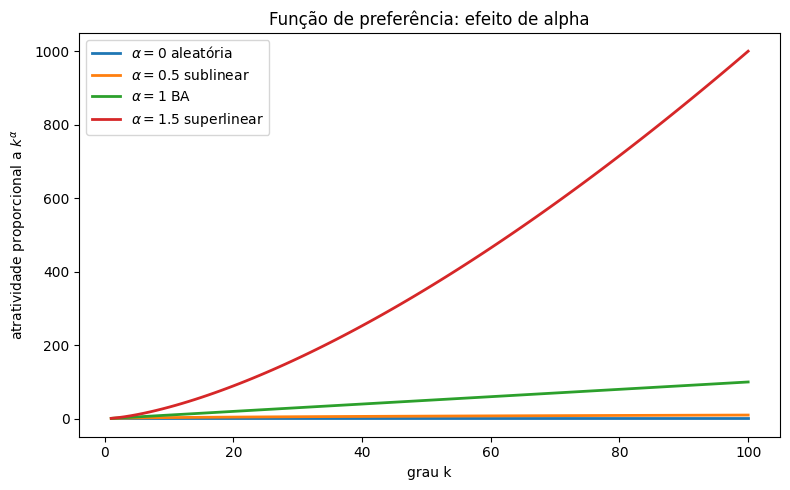

In [2]:
# =========================
# Parte 1 — Função de preferência
# =========================

k = np.arange(1, 101)

curves = {
    r"$\alpha = 0$ aleatória": k**0,
    r"$\alpha = 0.5$ sublinear": k**0.5,
    r"$\alpha = 1$ BA": k**1.0,
    r"$\alpha = 1.5$ superlinear": k**1.5,
}

plt.figure(figsize=(8, 5))

for label, y in curves.items():
    plt.plot(k, y, linewidth=2, label=label)

plt.xlabel("grau k")
plt.ylabel(r"atratividade proporcional a $k^\alpha$")
plt.title("Função de preferência: efeito de alpha")
plt.legend()
plt.tight_layout()
plt.savefig("images/JL/funcao_preferencia_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

# Parte 2 — Simulação com preferência aleatória, sublinear, linear e superlinear

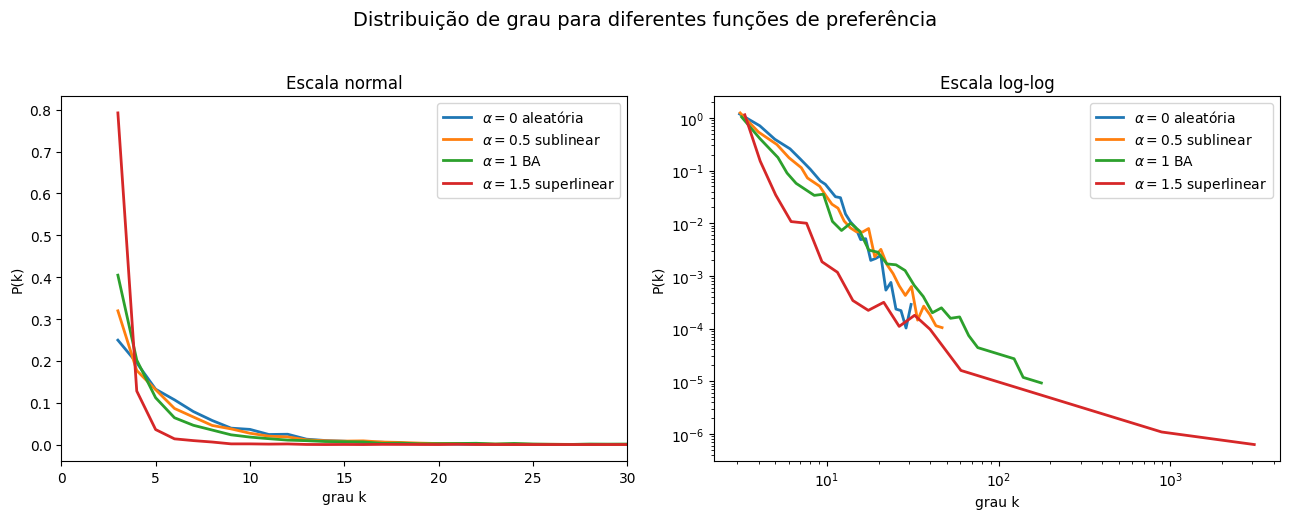

In [3]:
# =========================
# Parte 2 — Preferência aleatória, sublinear, linear e superlinear
# =========================

def nonlinear_attachment_network(N=5000, m=3, alpha=1.0, A=0.0):
    """
    Rede em crescimento.
    Cada novo nó conecta-se a m nós antigos.

    A probabilidade de escolher um nó antigo é proporcional a:

        w(k) = k^alpha + A

    alpha = 0   -> escolha aleatória
    alpha = 0.5 -> preferência sublinear
    alpha = 1   -> BA clássico
    alpha = 1.5 -> preferência superlinear
    """
    m0 = max(m + 2, 5)
    G = nx.complete_graph(m0)

    for new_node in range(m0, N):
        G.add_node(new_node)

        old_nodes = list(range(new_node))
        degrees = [G.degree(v) for v in old_nodes]
        weights = attachment_weights(degrees, alpha=alpha, A=A)

        targets = preferential_choice(old_nodes, weights, size=m)

        for target in targets:
            G.add_edge(new_node, target)

    return G


N = 5000
m = 3

models_alpha = {
    r"$\alpha=0$ aleatória": nonlinear_attachment_network(N=N, m=m, alpha=0.0, A=0.0),
    r"$\alpha=0.5$ sublinear": nonlinear_attachment_network(N=N, m=m, alpha=0.5, A=0.0),
    r"$\alpha=1$ BA": nonlinear_attachment_network(N=N, m=m, alpha=1.0, A=0.0),
    r"$\alpha=1.5$ superlinear": nonlinear_attachment_network(N=N, m=m, alpha=1.5, A=0.0),
}

plot_distribution_linear_and_log(
    models_alpha,
    title="Distribuição de grau para diferentes funções de preferência",
    degree_mode="degree",
    bins=35,
    xlim_quantile=0.995,
    save_path="images/JL/distribuicao_alpha_normal_loglog.png"
)

# Parte 3 — Atratividade inicial A

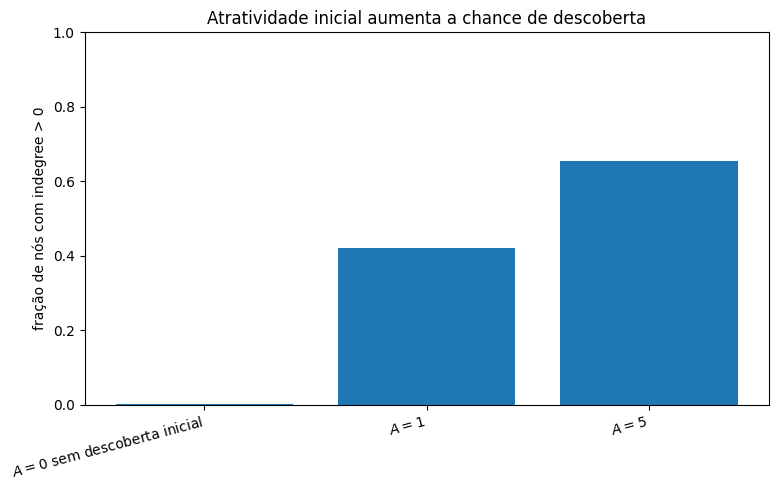

In [4]:
# =========================
# Parte 3 — Atratividade inicial A
# =========================

def citation_network_with_attractiveness(N=5000, m=3, alpha=1.0, A=1.0):
    """
    Modelo direcionado inspirado em citações.

    Cada novo nó cria m arestas saindo dele para nós antigos.
    A chance de um nó antigo receber citação é proporcional a:

        w(k_in) = k_in^alpha + A

    k_in = número de citações recebidas.
    A = atratividade inicial.
    """
    m0 = max(m + 2, 5)
    G = nx.DiGraph()

    # Núcleo inicial: todo mundo aponta para todo mundo
    for i in range(m0):
        G.add_node(i)

    for i in range(m0):
        for j in range(m0):
            if i != j:
                G.add_edge(i, j)

    for new_node in range(m0, N):
        G.add_node(new_node)

        old_nodes = list(range(new_node))
        indegrees = [G.in_degree(v) for v in old_nodes]
        weights = attachment_weights(indegrees, alpha=alpha, A=A)

        targets = preferential_choice(old_nodes, weights, size=m)

        for target in targets:
            G.add_edge(new_node, target)

    return G


def plot_discovered_fraction(models, save_path=None):
    """
    Fração de nós que receberam pelo menos uma conexão.
    Em rede de citação, isso significa indegree > 0.
    """
    names = []
    fractions = []

    for name, G in models.items():
        indegrees = [d for _, d in G.in_degree()]
        discovered = sum(1 for d in indegrees if d > 0)
        fractions.append(discovered / len(indegrees))
        names.append(name)

    plt.figure(figsize=(8, 5))
    plt.bar(names, fractions)
    plt.ylabel("fração de nós com indegree > 0")
    plt.title("Atratividade inicial aumenta a chance de descoberta")
    plt.ylim(0, 1)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


models_A = {
    r"$A=0$ sem descoberta inicial": citation_network_with_attractiveness(N=5000, m=3, alpha=1.0, A=0.0),
    r"$A=1$": citation_network_with_attractiveness(N=5000, m=3, alpha=1.0, A=1.0),
    r"$A=5$": citation_network_with_attractiveness(N=5000, m=3, alpha=1.0, A=5.0),
}

plot_discovered_fraction(
    models_A,
    save_path="images/JL/fracao_descobertos_A.png"
)

# Parte 4 — Crescimento acelerado: com e sem arestas extras

In [5]:
# =========================
# Parte 4 — Crescimento acelerado
# =========================

def growing_network_with_optional_acceleration(
    N=5000,
    m=3,
    alpha=1.0,
    A=0.0,
    accelerated=False,
    c0=0.012,
    theta=0.8
):
    """
    Rede não direcionada em crescimento.

    Caso BA clássico:
    - cada novo nó entra com m arestas.

    Caso acelerado:
    - além das m arestas do novo nó,
      adicionamos arestas extras entre nós antigos.
    - número de arestas extras cresce como c0 * t^theta.
    """
    m0 = max(m + 2, 5)
    G = nx.complete_graph(m0)

    history_N = []
    history_E = []
    history_avg_degree = []
    history_max_degree = []

    for new_node in range(m0, N):
        G.add_node(new_node)

        old_nodes = list(range(new_node))
        degrees = [G.degree(v) for v in old_nodes]
        weights = attachment_weights(degrees, alpha=alpha, A=A)

        targets = preferential_choice(old_nodes, weights, size=m)

        for target in targets:
            G.add_edge(new_node, target)

        if accelerated:
            extra_edges = int(c0 * (new_node ** theta))

            for _ in range(extra_edges):
                nodes = list(G.nodes())

                # origem aleatória
                u = random.choice(nodes)

                # destino preferencial, evitando laço e aresta repetida
                possible_targets = [
                    v for v in nodes
                    if v != u and not G.has_edge(u, v)
                ]

                if len(possible_targets) == 0:
                    continue

                target_degrees = [G.degree(v) for v in possible_targets]
                target_weights = attachment_weights(target_degrees, alpha=alpha, A=A)

                v = preferential_choice(possible_targets, target_weights, size=1)[0]
                G.add_edge(u, v)

        history_N.append(G.number_of_nodes())
        history_E.append(G.number_of_edges())
        history_avg_degree.append(2 * G.number_of_edges() / G.number_of_nodes())
        history_max_degree.append(max(dict(G.degree()).values()))

    history = {
        "N": history_N,
        "E": history_E,
        "avg_degree": history_avg_degree,
        "max_degree": history_max_degree
    }

    return G, history


G_normal, hist_normal = growing_network_with_optional_acceleration(
    N=5000,
    m=3,
    alpha=1.0,
    A=0.0,
    accelerated=False
)

G_accel, hist_accel = growing_network_with_optional_acceleration(
    N=5000,
    m=3,
    alpha=1.0,
    A=0.0,
    accelerated=True,
    c0=0.012,
    theta=0.8
)

models_growth = {
    "BA clássico": G_normal,
    "crescimento acelerado": G_accel
}

## Gráfico 1 do crescimento acelerado — grau médio no tempo

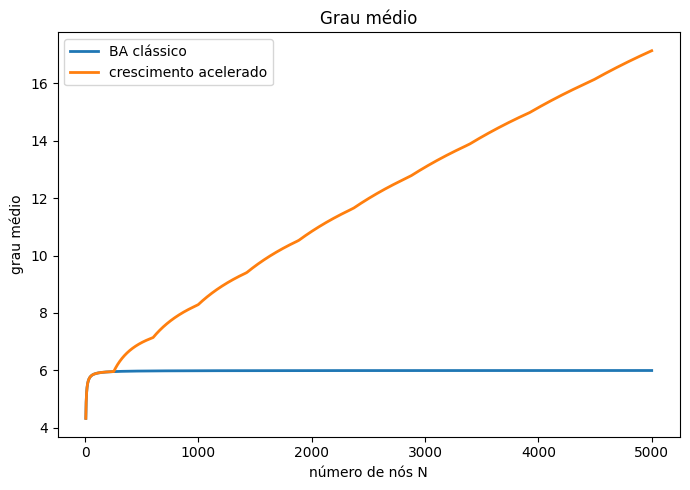

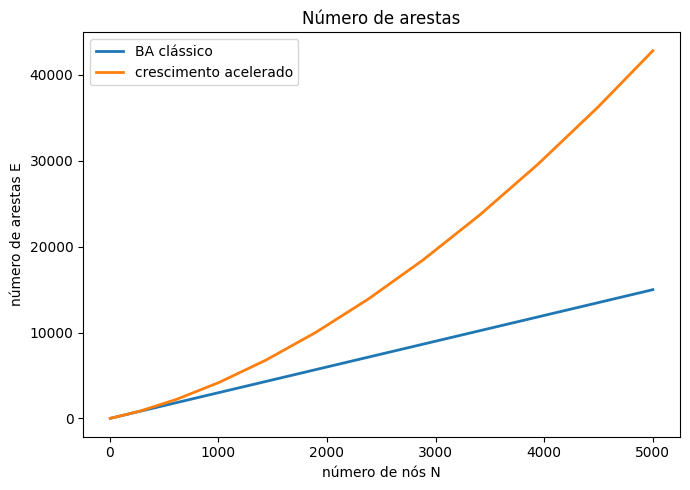

In [9]:
# =========================
# Crescimento acelerado — evolução temporal
# =========================

plt.figure(figsize=(7, 5))
plt.plot(hist_normal["N"], hist_normal["avg_degree"], linewidth=2, label="BA clássico")
plt.plot(hist_accel["N"], hist_accel["avg_degree"], linewidth=2, label="crescimento acelerado")
plt.xlabel("número de nós N")
plt.ylabel("grau médio")
plt.title("Grau médio")
plt.legend()
plt.tight_layout()
plt.savefig("images/JL/crescimento_acelerado_grau_medio.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(hist_normal["N"], hist_normal["E"], linewidth=2, label="BA clássico")
plt.plot(hist_accel["N"], hist_accel["E"], linewidth=2, label="crescimento acelerado")
plt.xlabel("número de nós N")
plt.ylabel("número de arestas E")
plt.title("Número de arestas")
plt.legend()
plt.tight_layout()
plt.savefig("images/JL/crescimento_acelerado_arestas.png", dpi=300, bbox_inches="tight")
plt.show()

## Gráfico 3 do crescimento acelerado — distribuição de grau

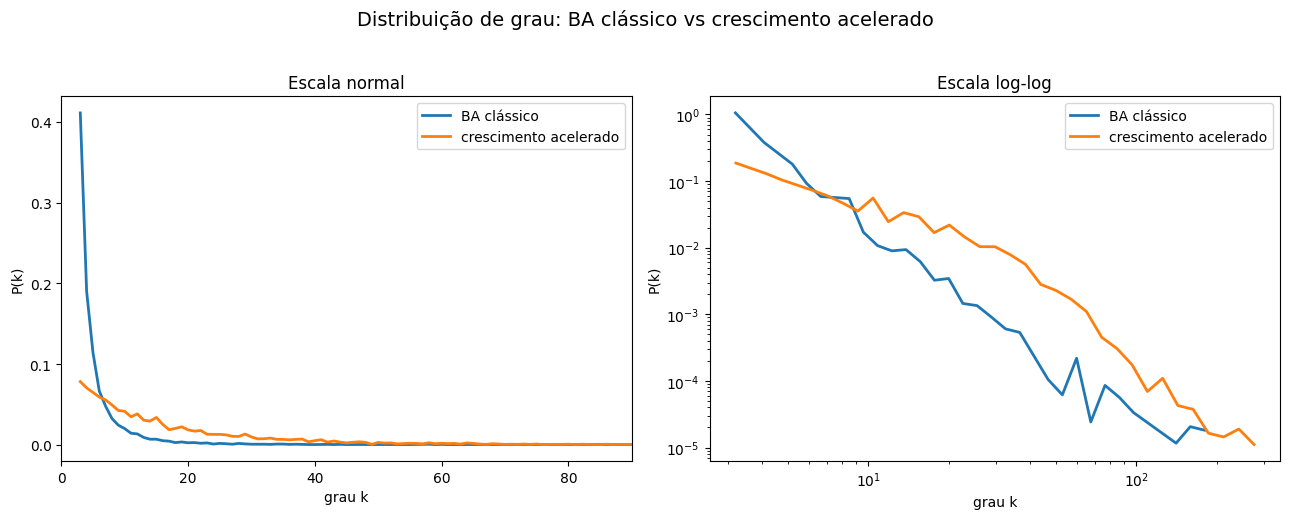

In [7]:
# =========================
# Crescimento acelerado — distribuição final
# =========================

plot_distribution_linear_and_log(
    models_growth,
    title="Distribuição de grau: BA clássico vs crescimento acelerado",
    degree_mode="degree",
    bins=35,
    xlim_quantile=0.995,
    save_path="images/JL/distribuicao_crescimento_normal_loglog.png"
)

# Fim

In [8]:
# =========================
# Resumo numérico dos modelos
# =========================

def summarize_undirected_models(models):
    rows = []

    for name, G in models.items():
        degrees = np.array([d for _, d in G.degree()])

        rows.append({
            "modelo": name,
            "N": G.number_of_nodes(),
            "E": G.number_of_edges(),
            "grau_médio": degrees.mean(),
            "grau_mediano": np.median(degrees),
            "grau_máximo": degrees.max(),
            "percentil_95": np.quantile(degrees, 0.95),
            "percentil_99": np.quantile(degrees, 0.99),
        })

    return rows


def summarize_directed_models(models):
    rows = []

    for name, G in models.items():
        indegrees = np.array([d for _, d in G.in_degree()])

        rows.append({
            "modelo": name,
            "N": G.number_of_nodes(),
            "E": G.number_of_edges(),
            "indegree_médio": indegrees.mean(),
            "indegree_mediano": np.median(indegrees),
            "indegree_máximo": indegrees.max(),
            "fração_descoberta": np.mean(indegrees > 0),
        })

    return rows


print("Modelos com alpha:")
for row in summarize_undirected_models(models_alpha):
    print(row)

print("\nModelos com atratividade inicial:")
for row in summarize_directed_models(models_A):
    print(row)

print("\nModelos com crescimento:")
for row in summarize_undirected_models(models_growth):
    print(row)

Modelos com alpha:
{'modelo': '$\\alpha=0$ aleatória', 'N': 5000, 'E': 14995, 'grau_médio': np.float64(5.998), 'grau_mediano': np.float64(5.0), 'grau_máximo': np.int64(32), 'percentil_95': np.float64(13.0), 'percentil_99': np.float64(18.0)}
{'modelo': '$\\alpha=0.5$ sublinear', 'N': 5000, 'E': 14995, 'grau_médio': np.float64(5.998), 'grau_mediano': np.float64(5.0), 'grau_máximo': np.int64(53), 'percentil_95': np.float64(14.0), 'percentil_99': np.float64(23.0)}
{'modelo': '$\\alpha=1$ BA', 'N': 5000, 'E': 14995, 'grau_médio': np.float64(5.998), 'grau_mediano': np.float64(4.0), 'grau_máximo': np.int64(213), 'percentil_95': np.float64(15.0), 'percentil_99': np.float64(34.0)}
{'modelo': '$\\alpha=1.5$ superlinear', 'N': 5000, 'E': 14995, 'grau_médio': np.float64(5.998), 'grau_mediano': np.float64(3.0), 'grau_máximo': np.int64(4205), 'percentil_95': np.float64(5.0), 'percentil_99': np.float64(11.0)}

Modelos com atratividade inicial:
{'modelo': '$A=0$ sem descoberta inicial', 'N': 5000, 'E'